# EDA y prueba de modelos — Detector de fallas de GPU

1. Carga de datos

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandera.pandas as pa

SENALES = ["temp_c", "power_w", "util_pct", "clock_mhz", "ecc_errors"]
ESTADOS = ["normal", "sobrecalentamiento", "degradacion_memoria", "falla_alimentacion"]

df = pd.read_csv("../data/telemetria_publica.csv")
df.head()

,episodio_id,segundo,temp_c,power_w,util_pct,clock_mhz,ecc_errors,estado
0,0,0,56.2,234.5,76.2,2412.0,0,normal
1,0,1,50.8,169.3,63.1,2403.0,0,normal
2,0,2,58.0,217.3,85.3,2396.0,0,normal
3,0,3,58.8,193.4,62.5,2448.0,0,normal
4,0,4,47.2,198.8,62.4,2381.0,0,normal


In [20]:
print("Filas:", len(df))
print("Nulos:", df.isna().sum().sum())
print("Episodios:", df["episodio_id"].nunique())

Filas: 14400
Nulos: 0
Episodios: 48


In [21]:
print("Segundos por episodio:", df.groupby("episodio_id").size().unique())
df.groupby("episodio_id")["estado"].first().value_counts()

Segundos por episodio: [300]


estado
normal                 12
sobrecalentamiento     12
degradacion_memoria    12
falla_alimentacion     12
Name: count, dtype: int64

2. Validación con pandera

In [23]:
esquema = pa.DataFrameSchema(
    {
        "episodio_id": pa.Column(int, pa.Check.ge(0)),
        "segundo": pa.Column(int, pa.Check.ge(0)),
        "temp_c": pa.Column(float, pa.Check.in_range(0, 110)),
        "power_w": pa.Column(float, [pa.Check.gt(0), pa.Check.le(400)]),
        "util_pct": pa.Column(float, pa.Check.in_range(0, 100)),
        "clock_mhz": pa.Column(float, pa.Check.in_range(0, 3000)),
        "ecc_errors": pa.Column(int, pa.Check.ge(0)),
        "estado": pa.Column(str, pa.Check.isin(ESTADOS)),
    },
    strict=True,
    drop_invalid_rows=True,
)

df_valido = esquema.validate(df, lazy=True)

In [25]:
descartadas = df[~df.index.isin(df_valido.index)]
print("Filas descartadas:", len(descartadas))
descartadas

Filas descartadas: 3


,episodio_id,segundo,temp_c,power_w,util_pct,clock_mhz,ecc_errors,estado
10907,36,107,56.7,-13.5,47.8,2020.0,0,falla_alimentacion
11662,38,262,50.1,-3.9,27.7,1844.0,0,falla_alimentacion
13358,44,158,55.3,-18.1,36.1,1714.0,0,falla_alimentacion


Las 3 filas descartadas tienen potencia negativa (imposible) y son de `falla_alimentacion`. Desde aquí se trabaja con `df_valido`.

3. EDA

Cada episodio (300 segundos) se resume en una sola fila con la media, mediana y desviación de cada señal. Este CSV es para **analizar**.

In [26]:
filas = []
for episodio, datos in df_valido.groupby("episodio_id"):
    fila = {"episodio_id": episodio, "estado": datos["estado"].iloc[0]}
    for col in SENALES:
        fila[f"{col}_media"] = datos[col].mean()
        fila[f"{col}_mediana"] = datos[col].median()
        fila[f"{col}_std"] = datos[col].std()
    filas.append(fila)

episodios = pd.DataFrame(filas).round(2)
episodios.to_csv("../data/resumen_episodios.csv", index=False)

print(episodios.shape)
episodios.head()

(48, 17)


,episodio_id,estado,temp_c_media,temp_c_mediana,temp_c_std,power_w_media,power_w_mediana,power_w_std,util_pct_media,util_pct_mediana,util_pct_std,clock_mhz_media,clock_mhz_mediana,clock_mhz_std,ecc_errors_media,ecc_errors_mediana,ecc_errors_std
0,0,normal,54.84,54.65,3.72,199.78,201.20,20.34,69.02,69.55,12.09,2401.26,2402.0,29.39,0.02,0.0,0.13
1,1,normal,54.42,54.40,4.10,197.44,199.85,19.46,70.39,70.75,12.24,2401.22,2400.0,30.34,0.03,0.0,0.18
2,2,normal,55.11,55.15,3.80,200.88,201.30,19.73,69.46,69.15,11.71,2398.73,2398.0,29.44,0.02,0.0,0.15
3,3,normal,54.94,55.10,4.10,197.90,198.35,19.79,70.93,70.90,11.87,2399.94,2401.0,29.56,0.02,0.0,0.13
4,4,normal,54.98,54.75,4.17,201.61,200.15,20.30,69.40,68.50,12.10,2402.52,2402.0,29.20,0.04,0.0,0.21


In [27]:
episodios.drop(columns="episodio_id").groupby("estado").mean().round(1).loc[ESTADOS].T

estado,normal,sobrecalentamiento,degradacion_memoria,falla_alimentacion
temp_c_media,54.9,88.0,60.0,50.0
temp_c_mediana,54.9,88.1,59.9,50.0
temp_c_std,4.0,3.0,5.0,8.0
power_w_media,200.1,290.3,209.1,140.6
power_w_mediana,200.0,290.4,209.3,140.0
power_w_std,20.0,10.1,25.1,44.8
util_pct_media,69.8,94.9,67.8,54.5
util_pct_mediana,69.4,95.1,67.9,54.2
util_pct_std,12.0,3.7,13.9,24.0
clock_mhz_media,2400.7,2098.6,2378.9,1798.6


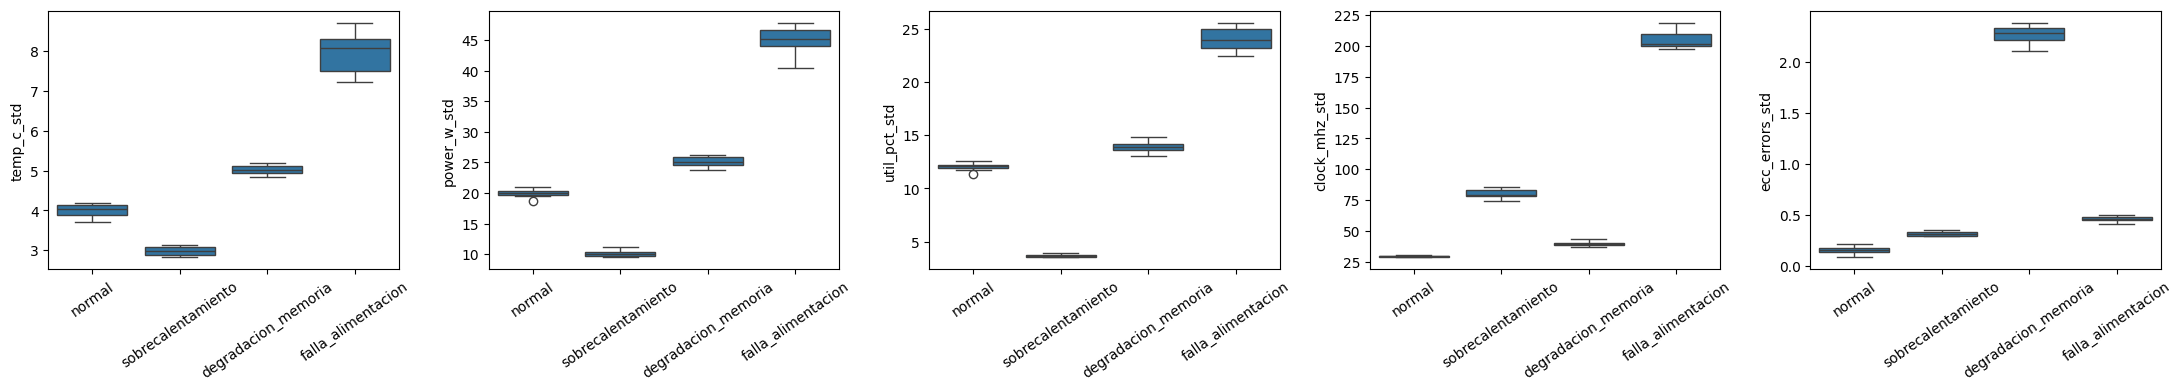

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, SENALES):
    sns.boxplot(data=episodios, x="estado", y=f"{col}_std", order=ESTADOS, ax=ax)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig("../reports/eda_episodios.png", dpi=110, bbox_inches="tight")
plt.show()

4. Creación ventaneo cada 30 s: el CSV para entrenar

Cada episodio se parte en 10 ventanas de 30 segundos (nunca se mezclan episodios). De cada ventana: media, mediana, desviación, mínimo y máximo. Por eso cada episodio aparece 10 veces: una por ventana.

In [29]:
def calcular_features(ventana):
    feats = {}
    for col in SENALES:
        feats[f"{col}_media"] = ventana[col].mean()
        feats[f"{col}_mediana"] = ventana[col].median()
        feats[f"{col}_std"] = ventana[col].std()
        feats[f"{col}_min"] = ventana[col].min()
        feats[f"{col}_max"] = ventana[col].max()
    return feats


filas = []
for (episodio, ventana_id), ventana in df_valido.groupby(["episodio_id", df_valido["segundo"] // 30]):
    fila = calcular_features(ventana)
    fila["estado"] = ventana["estado"].iloc[0]
    fila["episodio_id"] = episodio
    fila["ventana"] = ventana_id
    filas.append(fila)

features_train = pd.DataFrame(filas)
features_train.to_csv("../data/features_train.csv", index=False)

print(features_train.shape)
features_train[["episodio_id", "ventana", "estado", "temp_c_media", "clock_mhz_std", "ecc_errors_media"]].head(12)

(480, 28)


,episodio_id,ventana,estado,temp_c_media,clock_mhz_std,ecc_errors_media
0,0,0,normal,55.073333,28.463750,0.033333
1,0,1,normal,55.456667,37.306266,0.000000
2,0,2,normal,54.593333,24.232684,0.000000
3,0,3,normal,53.923333,25.135609,0.033333
4,0,4,normal,54.950000,25.582501,0.033333
5,0,5,normal,54.650000,33.027418,0.000000
6,0,6,normal,55.163333,25.738048,0.000000
7,0,7,normal,54.700000,24.768909,0.033333
8,0,8,normal,55.013333,36.489662,0.033333
9,0,9,normal,54.846667,31.864458,0.000000


## 5. Prueba de modelos

GroupKFold por episodio: las ventanas de un mismo episodio nunca quedan en train y test a la vez (si no, el modelo vería "gemelas" de las ventanas de prueba).

In [32]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = features_train.drop(columns=["estado", "episodio_id", "ventana"])
y = features_train["estado"]
grupos = features_train["episodio_id"]

modelos = {
    "Regresion logistica": LogisticRegression(max_iter=2000),
    "Arbol de decision": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

resultados = []
for nombre, modelo in modelos.items():
    pipe = make_pipeline(StandardScaler(), modelo)
    scores = cross_val_score(pipe, X, y, groups=grupos, cv=GroupKFold(n_splits=5))
    resultados.append({"modelo": nombre, "accuracy": scores.mean(), "std": scores.std()})

pd.DataFrame(resultados).sort_values("accuracy", ascending=False).round(4)

,modelo,accuracy,std
0,Regresion logistica,1.0000,0.0000
1,Arbol de decision,1.0000,0.0000
2,Random Forest,1.0000,0.0000
3,Gradient Boosting,0.9938,0.0081


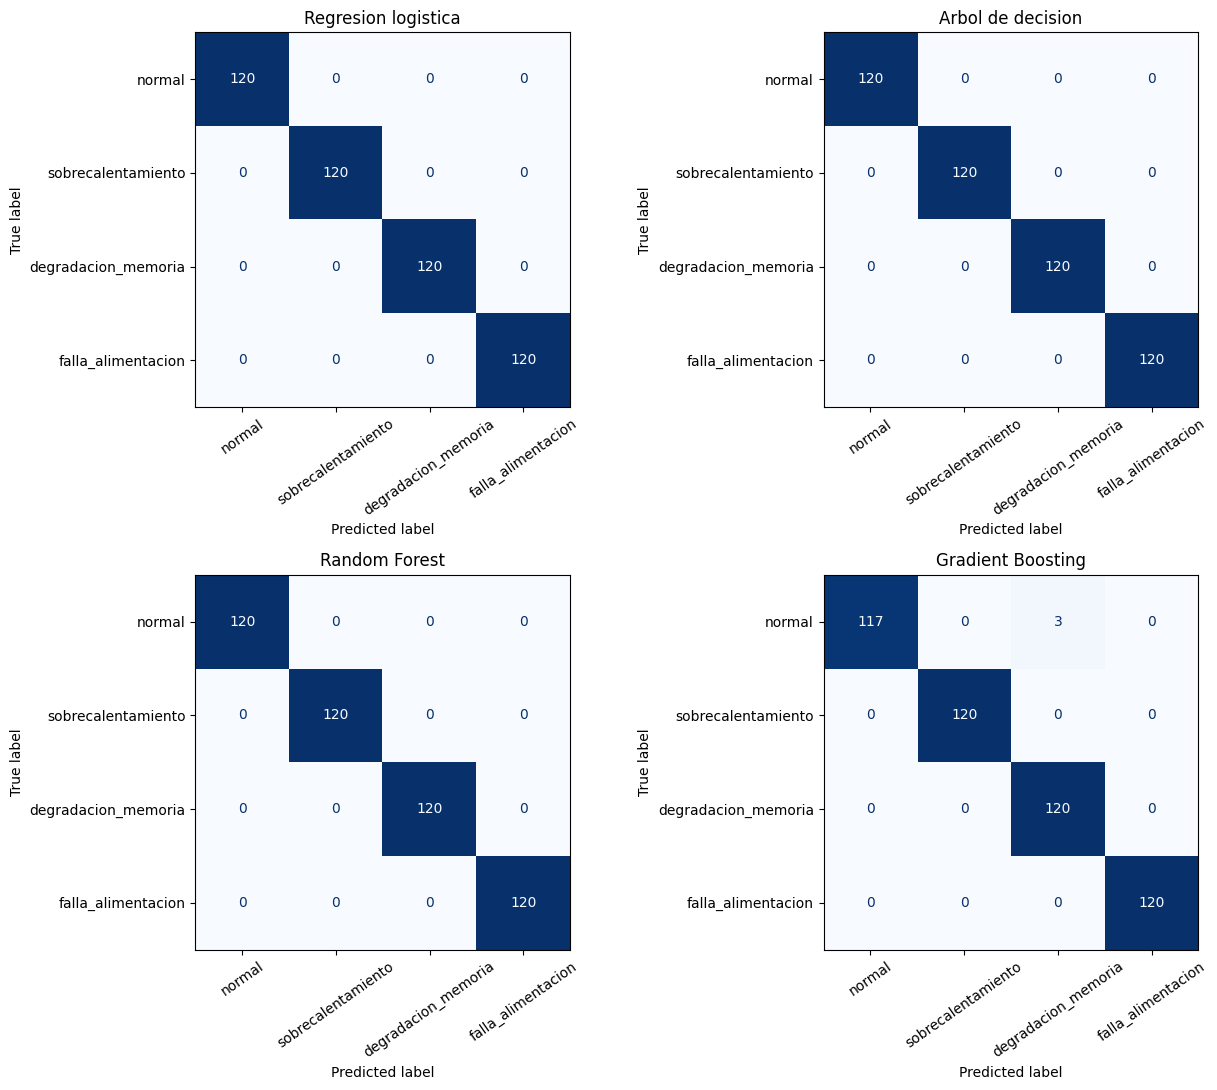

In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, (nombre, modelo) in zip(axes.ravel(), modelos.items()):
    pipe = make_pipeline(StandardScaler(), modelo)
    pred = cross_val_predict(pipe, X, y, groups=grupos, cv=GroupKFold(n_splits=5))
    ConfusionMatrixDisplay.from_predictions(y, pred, labels=ESTADOS, ax=ax,
                                            xticks_rotation=35, cmap="Blues", colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.savefig("../reports/matrices_confusion.png", dpi=110, bbox_inches="tight")
plt.show()